# 1.0 Install packages and import libraries

In [4]:
install.packages(c( "lme4"))

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘rbibutils’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’




In [23]:
library(lme4)
library(ggplot2)

# 2.0 Data load

In [35]:
url_df <- "https://raw.githubusercontent.com/maurope/lmf/main/data/2026_09_11_R_bios_diets_anaylisis_for_alejandra/Additives_Bios_AM.csv"
df <- read.csv(url_df)

In [36]:
head(df)

,X.,Treatment,Additive,Batch,Run,Replication,Syrange_No,Sample_weight_g,DM_Incubated_mg,Digested_feed_mg,⋯,CH4_percentage_in_gas_8h,CH4_percentage_in_gas_24h,CH4_ml_g_DM_incubated_24h,CH4_ml_g_DMD._24h,CH4_g_g_DM_incubated_24h,CH4_g_g_DMD_24h,pH,NH4_ppm,BLANK_24H_promedio_corrida_ppm,Amonio_corregido_ppm
,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,T0,CTRL_PREM,95,1,1,3,0.5006,447.1,359.9,⋯,14.8,15.0,42.3,52.6,23.5,29.2,7.39,360.7,419.25,-58.55
2,2,T0,CTRL_PREM,95,1,2,4,0.5001,446.6,370.8,⋯,15.9,15.6,46.2,55.7,25.7,30.9,7.29,455.1,419.25,35.85
3,3,T0,CTRL_PREM,95,1,3,5,0.5002,446.7,351.8,⋯,16.0,15.9,42.3,53.7,23.5,29.8,7.21,404.6,419.25,-14.65
4,4,T0,CTRL_PREM,96,2,1,3,0.5003,446.8,330.8,⋯,15.3,15.7,43.5,58.8,24.2,32.6,7.57,357.6,363.40,-5.80
5,5,T0,CTRL_PREM,96,2,2,4,0.5000,446.6,350.9,⋯,16.4,16.0,44.9,57.2,24.9,31.7,7.40,292.2,363.40,-71.20
6,6,T0,CTRL_PREM,96,2,3,5,0.5001,446.6,351.1,⋯,16.4,16.1,44.9,57.1,24.9,31.7,7.43,359.6,363.40,-3.80


# 3.0 Summary

In [37]:
nrow(df)  # number of rows
ncol(df)  # number of columns

[1] 333

[1] 24

In [38]:
names(df) # Columns names

[1] "X."                             "Treatment"                     
 [3] "Additive"                       "Batch"                         
 [5] "Run"                            "Replication"                   
 [7] "Syrange_No"                     "Sample_weight_g"               
 [9] "DM_Incubated_mg"                "Digested_feed_mg"              
[11] "CH4_24h_ml"                     "Gas_ml_g_DM_Incubated_24h"     
[13] "TDDM_percentage"                "Part_Fact"                     
[15] "CH4_percentage_in_gas_8h"       "CH4_percentage_in_gas_24h"     
[17] "CH4_ml_g_DM_incubated_24h"      "CH4_ml_g_DMD._24h"             
[19] "CH4_g_g_DM_incubated_24h"       "CH4_g_g_DMD_24h"               
[21] "pH"                             "NH4_ppm"                       
[23] "BLANK_24H_promedio_corrida_ppm" "Amonio_corregido_ppm"

In [59]:
glimpse(df)

Rows: 333
Columns: 24
$ X.                             <int> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, …
$ Treatment                      <chr> "T0", "T0", "T0", "T0", "T0", "T0", "T0…
$ Additive                       <chr> "CTRL_PREM", "CTRL_PREM", "CTRL_PREM", …
$ Batch                          <int> 95, 95, 95, 96, 96, 96, 97, 97, 97, 95,…
$ Run                            <int> 1, 1, 1, 2, 2, 2, 3, 3, 3, 1, 1, 1, 2, …
$ Replication                    <int> 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, …
$ Syrange_No                     <int> 3, 4, 5, 3, 4, 5, 3, 4, 5, 6, 7, 8, 6, …
$ Sample_weight_g                <dbl> 0.5006, 0.5001, 0.5002, 0.5003, 0.5000,…
$ DM_Incubated_mg                <dbl> 447.1, 446.6, 446.7, 446.8, 446.6, 446.…
$ Digested_feed_mg               <dbl> 359.9, 370.8, 351.8, 330.8, 350.9, 351.…
$ CH4_24h_ml                     <dbl> 18.9, 20.7, 18.9, 19.5, 20.1, 20.1, 19.…
$ Gas_ml_g_DM_Incubated_24h      <dbl> 282.7, 296.4, 266.2, 277.8, 281.3, 279.…
$ TDDM_percentage 

# 4.0 Data visualization

## 4.1 Boxplot TDDM %

Warning message:
“Removed 5 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_point()`).”


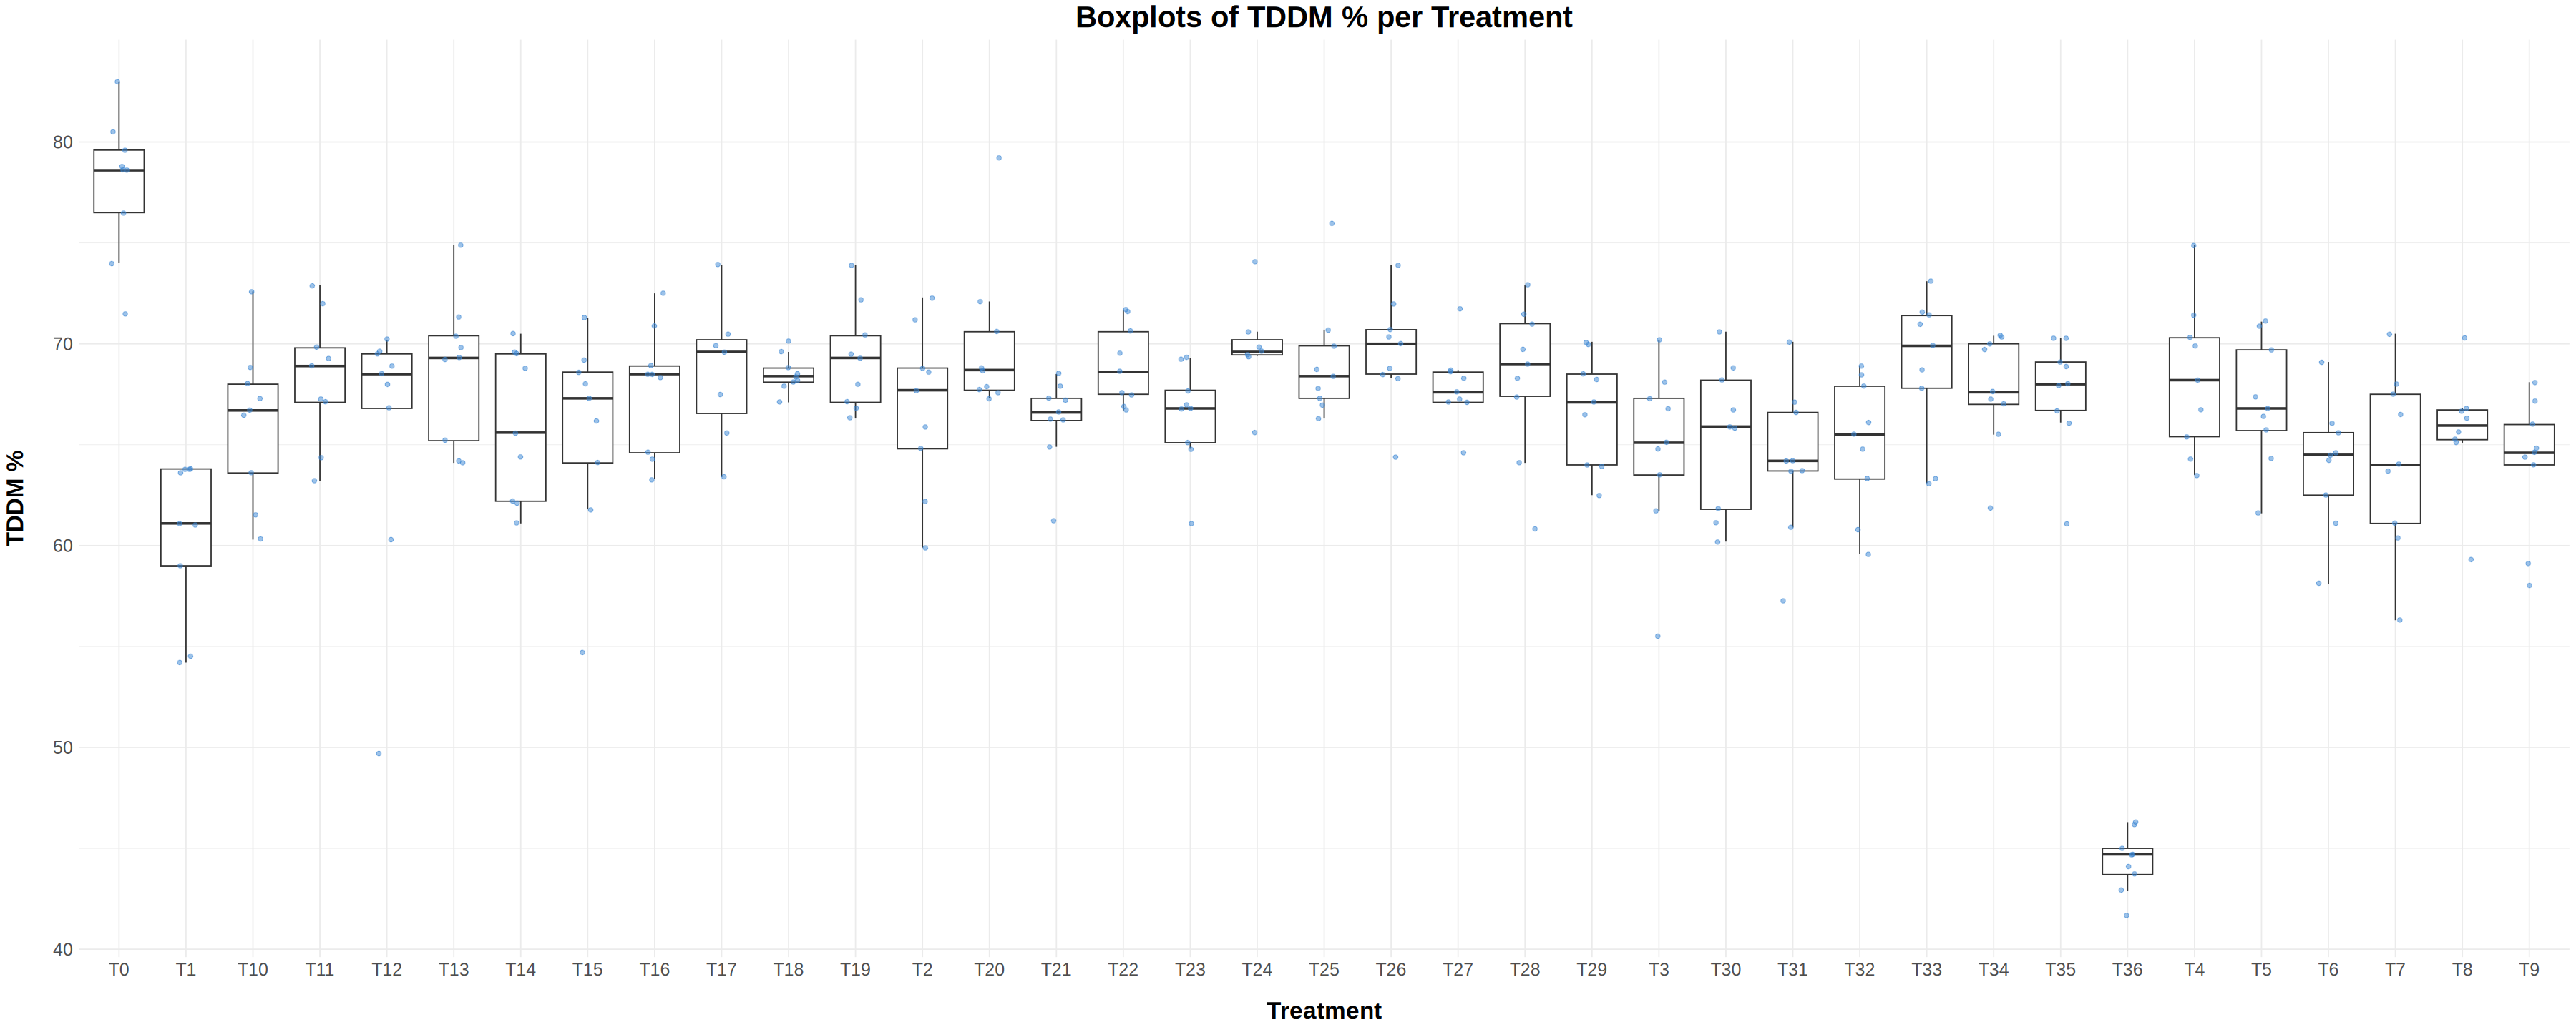

In [61]:
options(repr.plot.width=30, repr.plot.height=12)
ggplot(df, aes(x = Treatment, y = TDDM_percentage)) +
      geom_boxplot(outlier.shape = NA) +
      geom_jitter(width = 0.15, alpha = 0.5, color = "#3a86d4") +
      labs(title = "Boxplots of TDDM % per Treatment", x = "Treatment", y = "TDDM %") +
      theme_minimal() +
      theme(
        plot.title = element_text(size = 25, face = "bold", hjust = 0.5),
        axis.title.x = element_text(size = 20, face = "bold",  margin = margin(t = 20)),
        axis.title.y = element_text(size = 20, face = "bold",  margin = margin(r = 20)),
        axis.text.x = element_text(size = 15),
        axis.text.y = element_text(size = 15)
      )

## 4.2 Boxplot Methane Intensity

Warning message:
“Removed 5 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_point()`).”


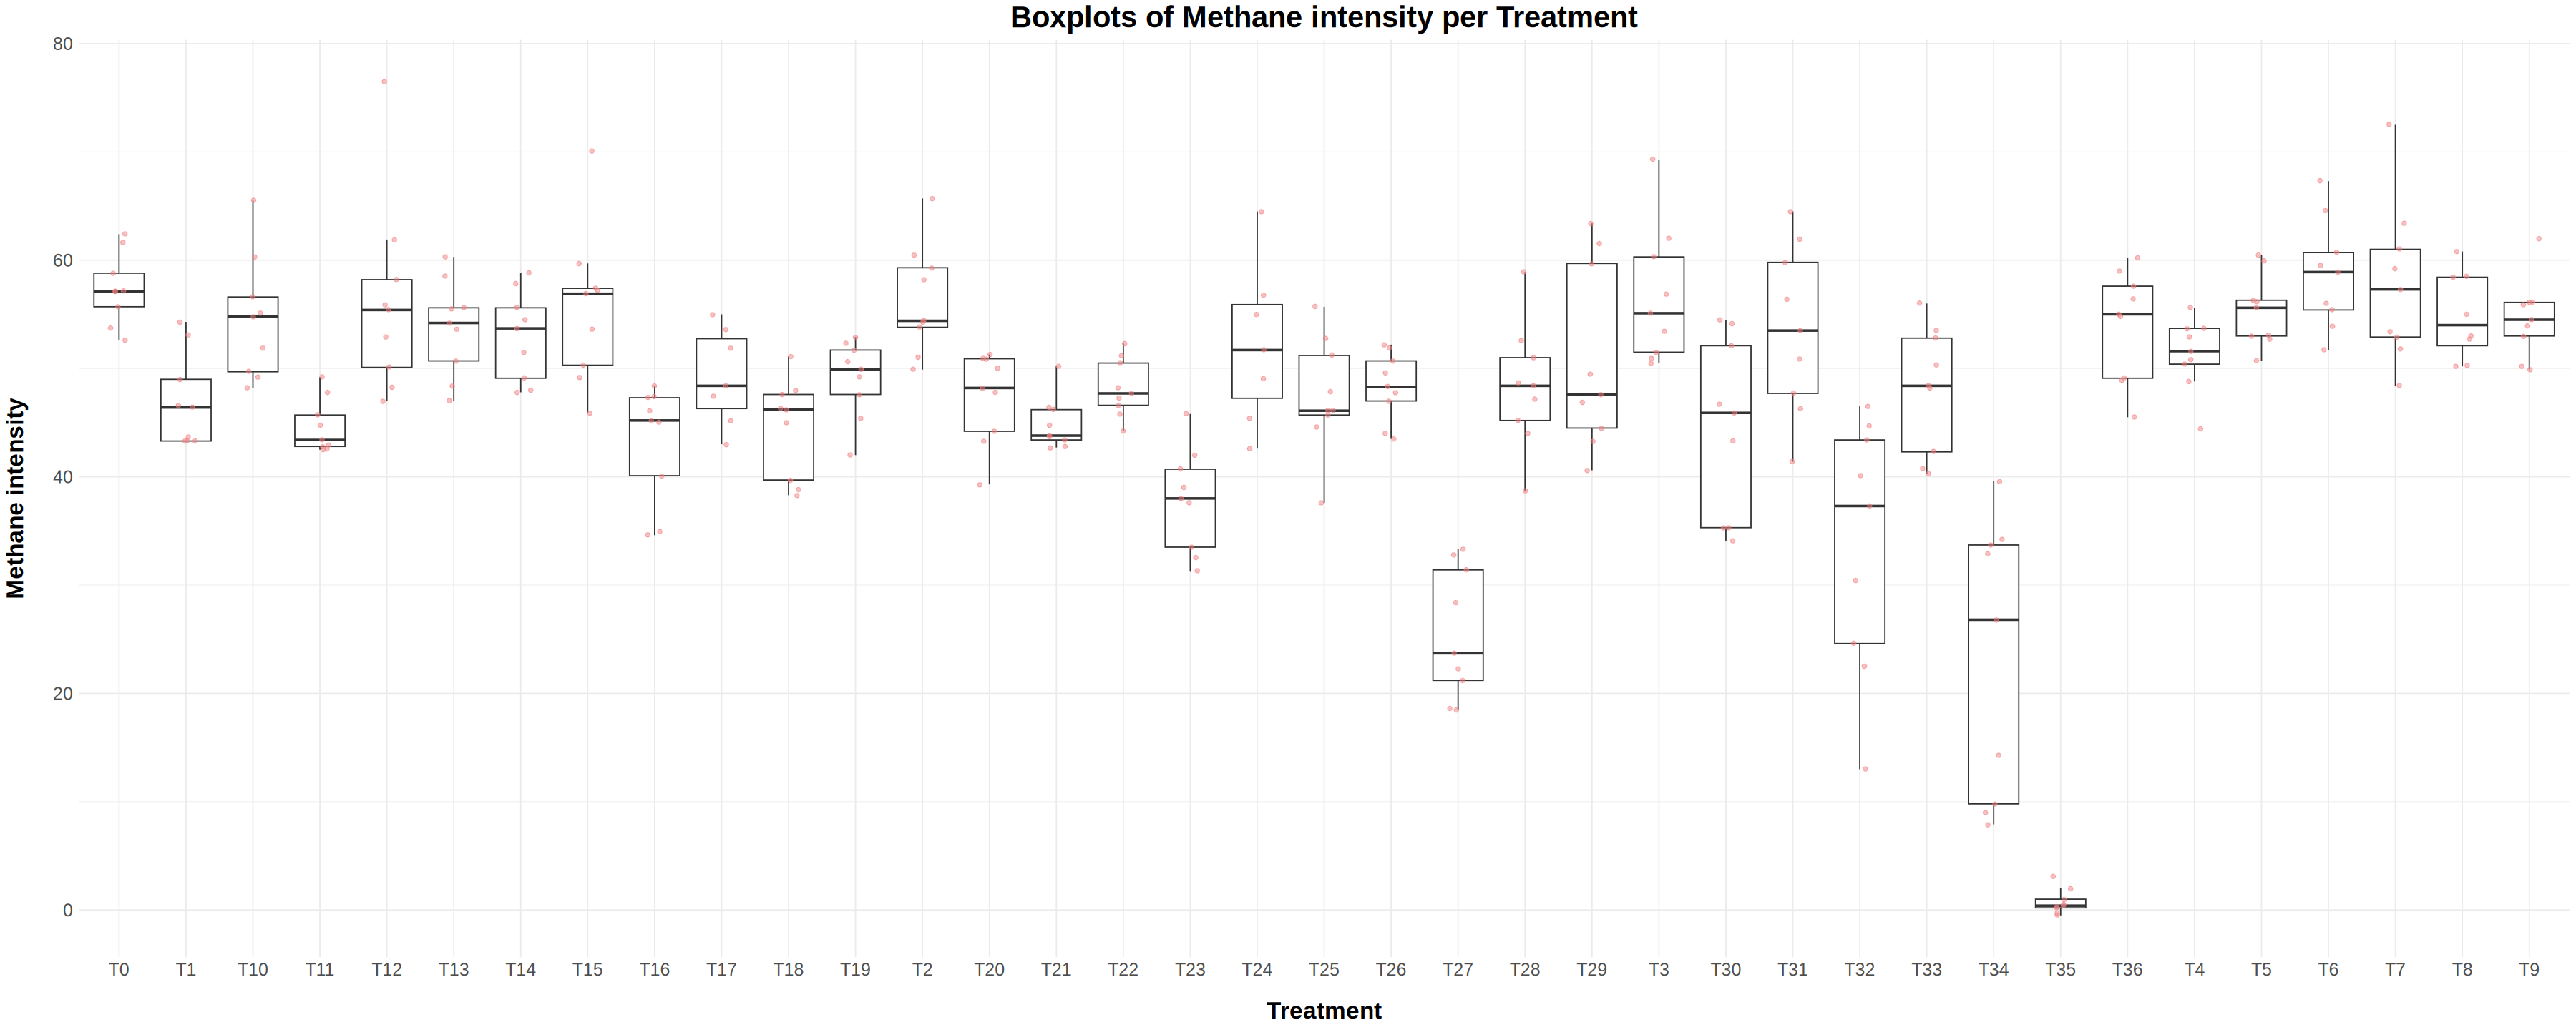

In [66]:
options(repr.plot.width=30, repr.plot.height=12)
ggplot(df, aes(x = Treatment, y = CH4_ml_g_DMD._24h)) +
      geom_boxplot(outlier.shape = NA) +
      geom_jitter(width = 0.15, alpha = 0.5, color = "lightcoral") +
      labs(title = "Boxplots of Methane intensity per Treatment", x = "Treatment", y = "Methane intensity") +
      theme_minimal() +
      theme(
        plot.title = element_text(size = 25, face = "bold", hjust = 0.5),
        axis.title.x = element_text(size = 20, face = "bold",  margin = margin(t = 20)),
        axis.title.y = element_text(size = 20, face = "bold",  margin = margin(r = 20)),
        axis.text.x = element_text(size = 15),
        axis.text.y = element_text(size = 15)
      )